# 04 — Temporal-MPS influence-matrix baseline and nested-ensemble driven scaling

This notebook produces the two figures added in the v9 revision of the paper:

1. **`fig_driven_scaling_ensemble`** — the strengthened driven-star validation:
   final-time log-errors of L0 and L0+G1 over *nested ensembles* (each leaf's
   intrinsic parameters depend only on `(seed, leaf index)`, so increasing $d$
   *adds* leaves without redrawing the existing ones), averaged over seeds.
2. **`fig_tmps_baseline`** — a head-to-head comparison of the Gaussian
   (L0+G1) message against a *temporal matrix-product influence-matrix (IM)
   baseline* (Bañuls et al. 2009; Strathearn et al. 2018 (TEMPO);
   Lerose–Sonner–Abanin 2021), implemented in `src/temporal_mps.py`.

**Method of the baseline** (Appendix "Temporal influence-matrix baseline" of the
paper): Trotterize the propagator with a symmetric (Strang) splitting; the world
line of one leaf then contracts, exactly, into an MPO over the hub time slices
with bond dimension 2.  Multiplying the $d$ leaf MPOs slice-wise with sequential
SVD compression to bond $\chi$ gives the IM baseline; the identical gate
sequence applied to the full statevector gives a *circuit-exact* reference, so
compression error is isolated from Trotter error.  At $\chi = 2^d$ the MPO
contraction reproduces the circuit-exact amplitude to machine precision (unit
test below).

The notebook follows a **load-or-compute** pattern: if the `.npz` data files are
already in `figures/`, it plots from them (seconds); set
`FORCE_RECOMPUTE = True` to regenerate everything from scratch
(≈ 3–4 minutes: the ensemble scan reaches $d=12$, Hilbert dimension $2^{13}$).


In [1]:
from pathlib import Path
import sys

# Works when the notebook is run from notebooks/ or from the repository root.
cwd = Path.cwd().resolve()
if cwd.name == "notebooks":
    ROOT = cwd.parent
else:
    candidates = [cwd] + list(cwd.parents)
    ROOT = next((p for p in candidates if (p / "experiments").is_dir() and (p / "src").is_dir()), cwd)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

FIGDIR = ROOT / "figures"
FIGDIR.mkdir(exist_ok=True)
print("repository root:", ROOT)


repository root: /Users/chertkov/Dropbox/Apps/Overleaf/QuantumSpinLoops/quantum_star_github


In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt

from src import star_qdp as q
from src import temporal_mps as tm

plt.rcParams.update({'font.size': 11, 'axes.grid': True, 'grid.alpha': 0.3})
FORCE_RECOMPUTE = False


## Unit tests of the baseline implementation

Three checks, mirroring the appendix:

* at $\chi = 2^d$ the compressed IM-MPO contraction equals the circuit-exact
  statevector amplitude to machine precision (same gates, same splitting);
* the circuit-exact amplitude converges to the continuum sparse oracle as the
  number of Trotter slices $n_s$ grows;
* compression at small $\chi$ degrades gracefully.


In [3]:
d, T, ns = 4, 2.0, 60
ts, B0t, bct, Kct, hub, leaves = tm.make_driven_star_instance_nested(d, ns + 1, T, seed=1)
a_circ = tm.circuit_exact(Kct, B0t, bct, T, ns, hub, leaves)
a_mpo, params, mb = tm.im_mpo_amplitude(Kct, B0t, bct, T, ns, hub, leaves, chi_max=2 ** d)
print(f"chi=2^d: |A_MPO - A_circuit| = {abs(a_mpo - a_circ):.3e}   (machine precision expected)")

nt_ref = 241
ts2, B0t2, bct2, Kct2, _, _ = tm.make_driven_star_instance_nested(d, nt_ref, T, seed=1)
a_cont = q.exact_sparse_driven(Kct2, B0t2, bct2, ts2, hub, leaves)[-1]
for ns_ in [40, 80, 160]:
    ts3, B0t3, bct3, Kct3, _, _ = tm.make_driven_star_instance_nested(d, ns_ + 1, T, seed=1)
    ac = tm.circuit_exact(Kct3, B0t3, bct3, T, ns_, hub, leaves)
    print(f"ns={ns_:4d}  |A_circuit - A_continuum| = {abs(ac - a_cont):.2e}")

for chi in [1, 2, 4, 8]:
    a_c, params, mb = tm.im_mpo_amplitude(Kct, B0t, bct, T, ns, hub, leaves, chi_max=chi)
    print(f"chi={chi}  compression error = {abs(a_c - a_circ):.3e}  message params = {params}")


chi=2^d: |A_MPO - A_circuit| = 5.467e-16   (machine precision expected)
ns=  40  |A_circuit - A_continuum| = 2.32e-04
ns=  80  |A_circuit - A_continuum| = 1.30e-04
ns= 160  |A_circuit - A_continuum| = 6.94e-05
chi=1  compression error = 5.668e-02  message params = 240
chi=2  compression error = 2.895e-02  message params = 944
chi=4  compression error = 3.051e-04  message params = 3744
chi=8  compression error = 7.537e-06  message params = 14624


ns=  40  |A_circuit - A_continuum| = 2.32e-04
ns=  80  |A_circuit - A_continuum| = 1.30e-04


ns= 160  |A_circuit - A_continuum| = 6.94e-05
chi=1  compression error = 5.668e-02  message params = 240
chi=2  compression error = 2.895e-02  message params = 944


chi=4  compression error = 3.051e-04  message params = 3744
chi=8  compression error = 7.537e-06  message params = 14624


## Figure 1: nested-ensemble driven-star scaling

Eight seeds, $d \in \{4,6,8,10,12\}$, $T=2$, kernels on $n_t = 161$ grid
points, sparse midpoint oracle as the exact reference.  Ensemble-mean slopes in
the paper: $-1.05$ (L0) and $-2.03$ (L0+G1); per-seed slopes
$-1.02 \pm 0.26$ and $-2.00 \pm 0.37$.


In [4]:
ens_npz = FIGDIR / "fig_driven_scaling_ensemble_data.npz"
T, nt = 2.0, 161
ds = [4, 6, 8, 10, 12]
seeds = list(range(1, 9))

if ens_npz.exists() and not FORCE_RECOMPUTE:
    dat = np.load(ens_npz)
    ds, E0, E1 = list(dat["ds"]), dat["E0"], dat["E1"]
    print("loaded", ens_npz.name)
else:
    E0 = np.zeros((len(seeds), len(ds)))
    E1 = np.zeros((len(seeds), len(ds)))
    t0 = time.time()
    for i, s in enumerate(seeds):
        for j, d in enumerate(ds):
            ts, B0t, bct, Kct, hub, leaves = tm.make_driven_star_instance_nested(d, nt, T, seed=s)
            a = q.exact_sparse_driven(Kct, B0t, bct, ts, hub, leaves)[-1]
            assert abs(np.angle(a)) < 3.0          # safe on the principal branch
            lL0, dG1 = q.L0G1_driven(Kct, B0t, bct, T, hub, leaves, nt=nt)
            E0[i, j] = abs(np.log(a) - lL0)
            E1[i, j] = abs(np.log(a) - lL0 - dG1)
        print(f"seed {s} done  [{time.time()-t0:.0f}s]", flush=True)
    sl0 = [q.fit_slope(ds, E0[i]) for i in range(len(seeds))]
    sl1 = [q.fit_slope(ds, E1[i]) for i in range(len(seeds))]
    np.savez(ens_npz, ds=ds, seeds=seeds, E0=E0, E1=E1,
             slope_l0_mean=q.fit_slope(ds, E0.mean(0)),
             slope_g1_mean=q.fit_slope(ds, E1.mean(0)),
             slope_l0_per=sl0, slope_g1_per=sl1, T=T, nt=nt)

m0, s0 = E0.mean(0), E0.std(0)
m1, s1 = E1.mean(0), E1.std(0)
sl0_mean, sl1_mean = q.fit_slope(ds, m0), q.fit_slope(ds, m1)
sl0_per = [q.fit_slope(ds, E0[i]) for i in range(E0.shape[0])]
sl1_per = [q.fit_slope(ds, E1[i]) for i in range(E1.shape[0])]
print(f"ensemble-mean slopes: L0 {sl0_mean:.2f},  L0+G1 {sl1_mean:.2f}")
print(f"per-seed slopes:      L0 {np.mean(sl0_per):.2f} +- {np.std(sl0_per):.2f},"
      f"  L0+G1 {np.mean(sl1_per):.2f} +- {np.std(sl1_per):.2f}")


loaded fig_driven_scaling_ensemble_data.npz
ensemble-mean slopes: L0 -1.05,  L0+G1 -2.03
per-seed slopes:      L0 -1.02 +- 0.26,  L0+G1 -2.00 +- 0.36


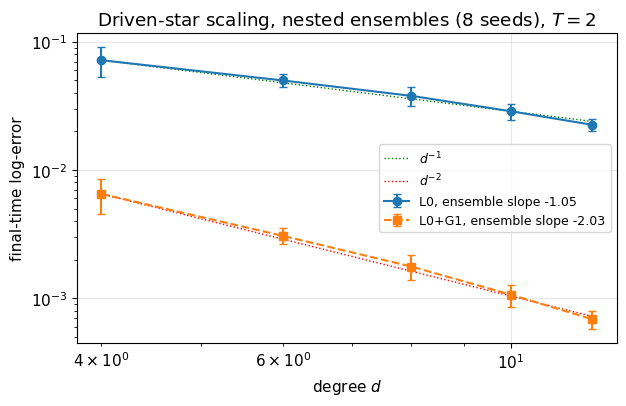

In [5]:
dsa = np.asarray(ds, float)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.errorbar(dsa, m0, yerr=s0, fmt='o-', color='C0', capsize=3,
            label=f"L0, ensemble slope {sl0_mean:.2f}")
ax.errorbar(dsa, m1, yerr=s1, fmt='s--', color='C1', capsize=3,
            label=f"L0+G1, ensemble slope {sl1_mean:.2f}")
ax.plot(dsa, m0[0] * (dsa / dsa[0]) ** -1, ':', color='green', lw=1, label=r'$d^{-1}$')
ax.plot(dsa, m1[0] * (dsa / dsa[0]) ** -2, ':', color='red', lw=1, label=r'$d^{-2}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('degree $d$'); ax.set_ylabel('final-time log-error')
ax.set_title(f"Driven-star scaling, nested ensembles ({E0.shape[0]} seeds), $T={T:g}$")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGDIR / 'fig_driven_scaling_ensemble.pdf')
fig.savefig(FIGDIR / 'fig_driven_scaling_ensemble.png', dpi=200)
plt.show()


## Figure 2: temporal-MPS influence-matrix baseline

Left panel — accuracy versus message size at $d=8$, $T=2$, coupling scale
$g=1$.  The IM curve sweeps $\chi$ against the circuit-exact reference
($n_s = 100$ slices), isolating the compression error; the dotted line is the
Trotter offset of the discretized dynamics from the continuum oracle.  The
L0+G1 diamonds store the aggregate Gaussian message
$(B_{\rm eff},\ \sum_c K_c \kappa_c K_c^{\sf T})$ on $n_t = 101$ and
$201$ grid points ($3 n_t + 9 n_t^2$ complex parameters) and are measured
against the continuum oracle.

Right panel — coupling-scale scan at fixed $d=8$: the L0+G1 error follows the
$\propto g^3$ growth of the first omitted cumulant; the fixed-$\chi$ IM error
grows more slowly, so the two methods exchange dominance across a crossover
surface in the $(d, \|K\|T)$ plane.


In [6]:
tmps_npz = FIGDIR / "fig_tmps_baseline_data.npz"
d, ns, ntg, T = 8, 100, 201, 2.0
chis = [1, 2, 3, 4, 6, 8, 16]
gs = [0.5, 1.0, 2.0, 3.0, 4.0]

if tmps_npz.exists() and not FORCE_RECOMPUTE:
    dat = dict(np.load(tmps_npz))
    print("loaded", tmps_npz.name)
else:
    dat = {}
    ts, B0t, bct, Kct, hub, leaves = tm.make_driven_star_instance_nested(d, ntg, T, seed=1)
    a_cont = q.exact_sparse_driven(Kct, B0t, bct, ts, hub, leaves)[-1]
    lL0, dG1 = q.L0G1_driven(Kct, B0t, bct, T, hub, leaves, nt=ntg)
    lL0c, dG1c = q.L0G1_driven(Kct[:, ::2], B0t[::2], bct[:, ::2], T, hub, leaves,
                               nt=(ntg + 1) // 2)
    dat["g1_err"] = abs(np.log(a_cont) - lL0 - dG1)
    dat["g1_err_coarse"] = abs(np.log(a_cont) - lL0c - dG1c)
    dat["g1_params"] = 3 * ntg + 9 * ntg ** 2
    dat["g1_params_coarse"] = 3 * ((ntg + 1) // 2) + 9 * ((ntg + 1) // 2) ** 2

    tsc, B0c, bcc, Kcc, _, _ = tm.make_driven_star_instance_nested(d, ns + 1, T, seed=1)
    a_circ = tm.circuit_exact(Kcc, B0c, bcc, T, ns, hub, leaves)
    dat["trotter_offset"] = abs(np.log(a_circ) - np.log(a_cont))
    mps_err, mps_par = [], []
    for chi in chis:
        a_c, params, mb = tm.im_mpo_amplitude(Kcc, B0c, bcc, T, ns, hub, leaves, chi)
        mps_err.append(abs(np.log(a_c) - np.log(a_circ))); mps_par.append(params)
        print(f"chi={chi:3d}  err={mps_err[-1]:.3e}  params={params}")
    dat["chis"], dat["mps_err"], dat["mps_par"] = chis, mps_err, mps_par

    gl0, gg1, gm2, gm4 = [], [], [], []
    for g in gs:
        ts, B0t, bct, Kct, hub, leaves = tm.make_driven_star_instance_nested(
            d, ntg, T, seed=1, coupling_scale=g)
        a2 = q.exact_sparse_driven(Kct, B0t, bct, ts, hub, leaves)[-1]
        l0, dg = q.L0G1_driven(Kct, B0t, bct, T, hub, leaves, nt=ntg)
        gl0.append(abs(np.log(a2) - l0)); gg1.append(abs(np.log(a2) - l0 - dg))
        tsc, B0c, bcc, Kcc, _, _ = tm.make_driven_star_instance_nested(
            d, ns + 1, T, seed=1, coupling_scale=g)
        ac = tm.circuit_exact(Kcc, B0c, bcc, T, ns, hub, leaves)
        gm2.append(abs(np.log(tm.im_mpo_amplitude(Kcc, B0c, bcc, T, ns, hub, leaves, 2)[0]) - np.log(ac)))
        gm4.append(abs(np.log(tm.im_mpo_amplitude(Kcc, B0c, bcc, T, ns, hub, leaves, 4)[0]) - np.log(ac)))
        print(f"g={g} done", flush=True)
    dat["gs"], dat["gl0"], dat["gg1"], dat["gm2"], dat["gm4"] = gs, gl0, gg1, gm2, gm4
    dat.update(d=d, T=T, ns=ns, ntg=ntg)
    np.savez(tmps_npz, **dat)


loaded fig_tmps_baseline_data.npz


## Coordination scan at fixed $\chi$ (panel b)

Errors of L0, L0+G1, and the IM baseline at fixed bond dimension
$\chi\in\{2,3,4\}$, all against the **common continuum oracle**, averaged
over four nested-ensemble seeds at $g=1$.  This panel locates the crossover:
L0+G1 falls as $d^{-2}$ while fixed-$\chi$ IM errors decay slowly
($\chi=2$: slope $\approx-0.9$; $\chi=3$: nearly flat), so the Gaussian
message overtakes $\chi=3$ near $d\approx8$; $\chi=4$ tracks the Trotter
floor in this window.


In [7]:
dsc_keys = ["dscan_ds", "dscan_chis", "dscan_E_l0", "dscan_E_g1", "dscan_E_im", "dscan_E_trot"]
have_dscan = tmps_npz.exists() and all(k in np.load(tmps_npz) for k in dsc_keys)
if have_dscan and not FORCE_RECOMPUTE:
    _d = np.load(tmps_npz)
    dscan = {k: _d[k] for k in dsc_keys}
    print("loaded d-scan from", tmps_npz.name)
else:
    ds_scan, seeds_scan, chis_scan = [4, 6, 8, 10, 12], [1, 2, 3, 4], [2, 3, 4]
    E_l0 = np.zeros((len(seeds_scan), len(ds_scan)))
    E_g1 = np.zeros_like(E_l0)
    E_im = np.zeros((len(seeds_scan), len(ds_scan), len(chis_scan)))
    E_tr = np.zeros_like(E_l0)
    for i, s in enumerate(seeds_scan):
        for j, dd in enumerate(ds_scan):
            ts, B0t, bct, Kct, hub, leaves = tm.make_driven_star_instance_nested(dd, ntg, T, seed=s)
            a_cont = q.exact_sparse_driven(Kct, B0t, bct, ts, hub, leaves)[-1]
            lg = np.log(a_cont)
            l0, dg = q.L0G1_driven(Kct, B0t, bct, T, hub, leaves, nt=ntg)
            E_l0[i, j] = abs(lg - l0); E_g1[i, j] = abs(lg - l0 - dg)
            tsc, B0c, bcc, Kcc, _, _ = tm.make_driven_star_instance_nested(dd, ns + 1, T, seed=s)
            a_circ = tm.circuit_exact(Kcc, B0c, bcc, T, ns, hub, leaves)
            E_tr[i, j] = abs(np.log(a_circ) - lg)
            for k, chi in enumerate(chis_scan):
                a_c, _, _ = tm.im_mpo_amplitude(Kcc, B0c, bcc, T, ns, hub, leaves, chi)
                E_im[i, j, k] = abs(np.log(a_c) - lg)
        print(f"seed {s} done", flush=True)
    dscan = dict(dscan_ds=ds_scan, dscan_chis=chis_scan, dscan_E_l0=E_l0,
                 dscan_E_g1=E_g1, dscan_E_im=E_im, dscan_E_trot=E_tr)
    dat.update(dscan)
    np.savez(tmps_npz, **dat)


seed 1 done
seed 2 done
seed 3 done
seed 4 done


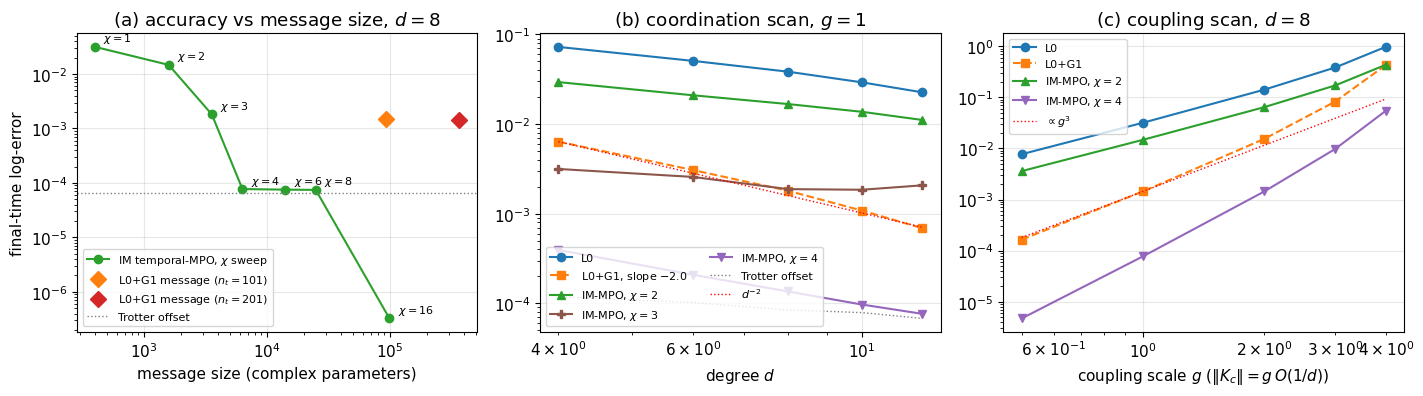

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.1))
ax = axes[0]
ax.plot(dat['mps_par'], dat['mps_err'], 'o-', color='C2', label='IM temporal-MPO, $\\chi$ sweep')
for chi, x, y in zip(np.atleast_1d(dat['chis']), np.atleast_1d(dat['mps_par']),
                     np.atleast_1d(dat['mps_err'])):
    ax.annotate(f"$\\chi={int(chi)}$", (x, y), textcoords='offset points',
                xytext=(6, 4), fontsize=8)
ax.plot([dat['g1_params_coarse']], [dat['g1_err_coarse']], 'D', color='C1', ms=8,
        label='L0+G1 message ($n_t=101$)')
ax.plot([dat['g1_params']], [dat['g1_err']], 'D', color='C3', ms=8,
        label='L0+G1 message ($n_t=201$)')
ax.axhline(float(dat['trotter_offset']), color='gray', ls=':', lw=1, label='Trotter offset')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('message size (complex parameters)')
ax.set_ylabel('final-time log-error')
ax.set_title(f"(a) accuracy vs message size, $d={int(dat['d'])}$")
ax.legend(fontsize=8, loc='lower left')

ax = axes[1]
dsa = np.asarray(dscan['dscan_ds'], float)
ax.plot(dsa, dscan['dscan_E_l0'].mean(0), 'o-', color='C0', label='L0')
ax.plot(dsa, dscan['dscan_E_g1'].mean(0), 's--', color='C1', label='L0+G1, slope $-2.0$')
mk, col = ['^', 'P', 'v'], ['C2', 'C5', 'C4']
for k, chi in enumerate(dscan['dscan_chis']):
    ax.plot(dsa, dscan['dscan_E_im'].mean(0)[:, k], mk[k] + '-', color=col[k],
            label=f'IM-MPO, $\\chi={int(chi)}$')
ax.plot(dsa, dscan['dscan_E_trot'].mean(0), ':', color='gray', lw=1, label='Trotter offset')
ax.plot(dsa, dscan['dscan_E_g1'].mean(0)[0] * (dsa / dsa[0]) ** -2, ':', color='red', lw=1,
        label=r'$d^{-2}$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('degree $d$')
ax.set_title('(b) coordination scan, $g=1$')
ax.legend(fontsize=8, loc='lower left', ncol=2)

ax = axes[2]
gsa = np.asarray(dat['gs'], float)
ax.plot(gsa, dat['gl0'], 'o-', color='C0', label='L0')
ax.plot(gsa, dat['gg1'], 's--', color='C1', label='L0+G1')
ax.plot(gsa, dat['gm2'], '^-', color='C2', label='IM-MPO, $\\chi=2$')
ax.plot(gsa, dat['gm4'], 'v-', color='C4', label='IM-MPO, $\\chi=4$')
ax.plot(gsa, np.asarray(dat['gg1'])[1] * (gsa / gsa[1]) ** 3, ':', color='red', lw=1,
        label=r'$\propto g^3$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('coupling scale $g$ ($\\|K_c\\| = g\\,O(1/d)$)')
ax.set_title(f"(c) coupling scan, $d={int(dat['d'])}$")
ax.legend(fontsize=8, loc='upper left')
fig.tight_layout()
fig.savefig(FIGDIR / 'fig_tmps_baseline.pdf')
fig.savefig(FIGDIR / 'fig_tmps_baseline.png', dpi=200)
plt.show()


## Takeaways

* At $d=8$ the IM baseline is the stronger primitive: $\chi=4$ reaches the
  Trotter floor with fewer parameters than the Gaussian message, whose accuracy
  here is limited by the $O(1/d^2)$ truncation, not by parameter count.
* The two messages are controlled by different parameters: IM by temporal
  entanglement (grows with coupling), the Gaussian message by $1/d$
  (shrinks with coordination) — complementary regimes with a crossover surface
  in the $(d, \|K\|T)$ plane.
* Structurally, the Gaussian message is **additive** across leaves and
  subtrees (aggregate size independent of $d$), while IM messages must be
  multiplied with managed bond growth — the reason to prefer cumulant messages
  on high-coordination trees, IM messages inside small strongly coupled
  clusters, and hybrids in between.
